# Curvas críticas densas en el intervalo empírico

Calcula puntos nuevos de materia nuclear **simétrica, y = 0.5**, para Dieterici y Clausius con VDW, CS y TVM. La malla por defecto es **K₀ = 250, 255, …, 315 MeV: 14 puntos por modelo, 84 en total**.

Se ajustan los parámetros de saturación para cada K₀ y se resuelven ∂P/∂n = ∂²P/∂n² = 0. No se interpolan los resultados previos. Esta es la transición líquido–gas hadrónica; Λ y las ramas asimétricas no intervienen en este cálculo simétrico.

Las figuras incluyen n_c frente a K₀ y T_c, como en la referencia, y n_c frente a α o c. **Las bandas en T_c son predicciones del modelo al imponer 250–315 MeV, no una restricción experimental independiente de T_c.** No se copian los límites experimentales de la imagen.

Ejecuta todas las celdas. Cada punto se guarda en `Paper/empirical_critical_K0_250_315/checkpoints`; puedes interrumpir y continuar. Los puntos fallidos se vuelven a intentar y no se dibujan como resultados válidos.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/qmm').is_dir())
sys.path.insert(0, str(ROOT / 'scripts'))
import compute_empirical_critical_scan as scan
from IPython.display import Image, display

K0_STEP = 5  # Cambia a 1 para 66 puntos por modelo.
K0_VALUES = sorted(set(range(250, 316, K0_STEP)) | {250, 315})
MODELS = scan.MODELS  # Ejemplo: ['dieterici_vdw', 'clausius_vdw']
FORCE = False  # True recalcula incluso los puntos ya guardados.
print(f'{len(K0_VALUES)} puntos por modelo; {len(K0_VALUES)*len(MODELS)} en total.')


14 puntos por modelo; 84 en total.


In [2]:
results = scan.run_scan(K0_VALUES, models=MODELS, force=FORCE)
display(results.groupby(['model_key', 'status']).size().rename('points').reset_index())
failed = results[results.status != 'ok']
if not failed.empty:
    display(failed)
    print('Hay puntos fallidos: vuelve a ejecutar esta celda para reintentarlos.')


dieterici_vdw K0=250: ok
dieterici_vdw K0=255: ok
dieterici_vdw K0=260: ok
dieterici_vdw K0=265: ok
dieterici_vdw K0=270: ok
dieterici_vdw K0=275: ok
dieterici_vdw K0=280: ok
dieterici_vdw K0=285: ok
dieterici_vdw K0=290: ok
dieterici_vdw K0=295: ok
dieterici_vdw K0=300: ok
dieterici_vdw K0=305: ok
dieterici_vdw K0=310: ok
dieterici_vdw K0=315: ok
dieterici_cs K0=250: ok
dieterici_cs K0=255: ok
dieterici_cs K0=260: ok
dieterici_cs K0=265: ok
dieterici_cs K0=270: ok
dieterici_cs K0=275: ok
dieterici_cs K0=280: ok
dieterici_cs K0=285: ok
dieterici_cs K0=290: ok
dieterici_cs K0=295: ok
dieterici_cs K0=300: ok
dieterici_cs K0=305: ok
dieterici_cs K0=310: ok
dieterici_cs K0=315: ok
dieterici_tvm K0=250: ok
dieterici_tvm K0=255: ok
dieterici_tvm K0=260: ok
dieterici_tvm K0=265: ok
dieterici_tvm K0=270: ok
dieterici_tvm K0=275: ok
dieterici_tvm K0=280: ok
dieterici_tvm K0=285: ok
dieterici_tvm K0=290: ok
dieterici_tvm K0=295: ok
dieterici_tvm K0=300: ok
dieterici_tvm K0=305: ok
dieterici_tvm 

,model_key,status,points
0,clausius_cs,ok,14
1,clausius_tvm,ok,14
2,clausius_vdw,ok,14
3,dieterici_cs,ok,14
4,dieterici_tvm,ok,14
5,dieterici_vdw,ok,14


Figuras PNG, PDF y SVG: /home/dajuarez4/QMM/Paper/empirical_critical_K0_250_315


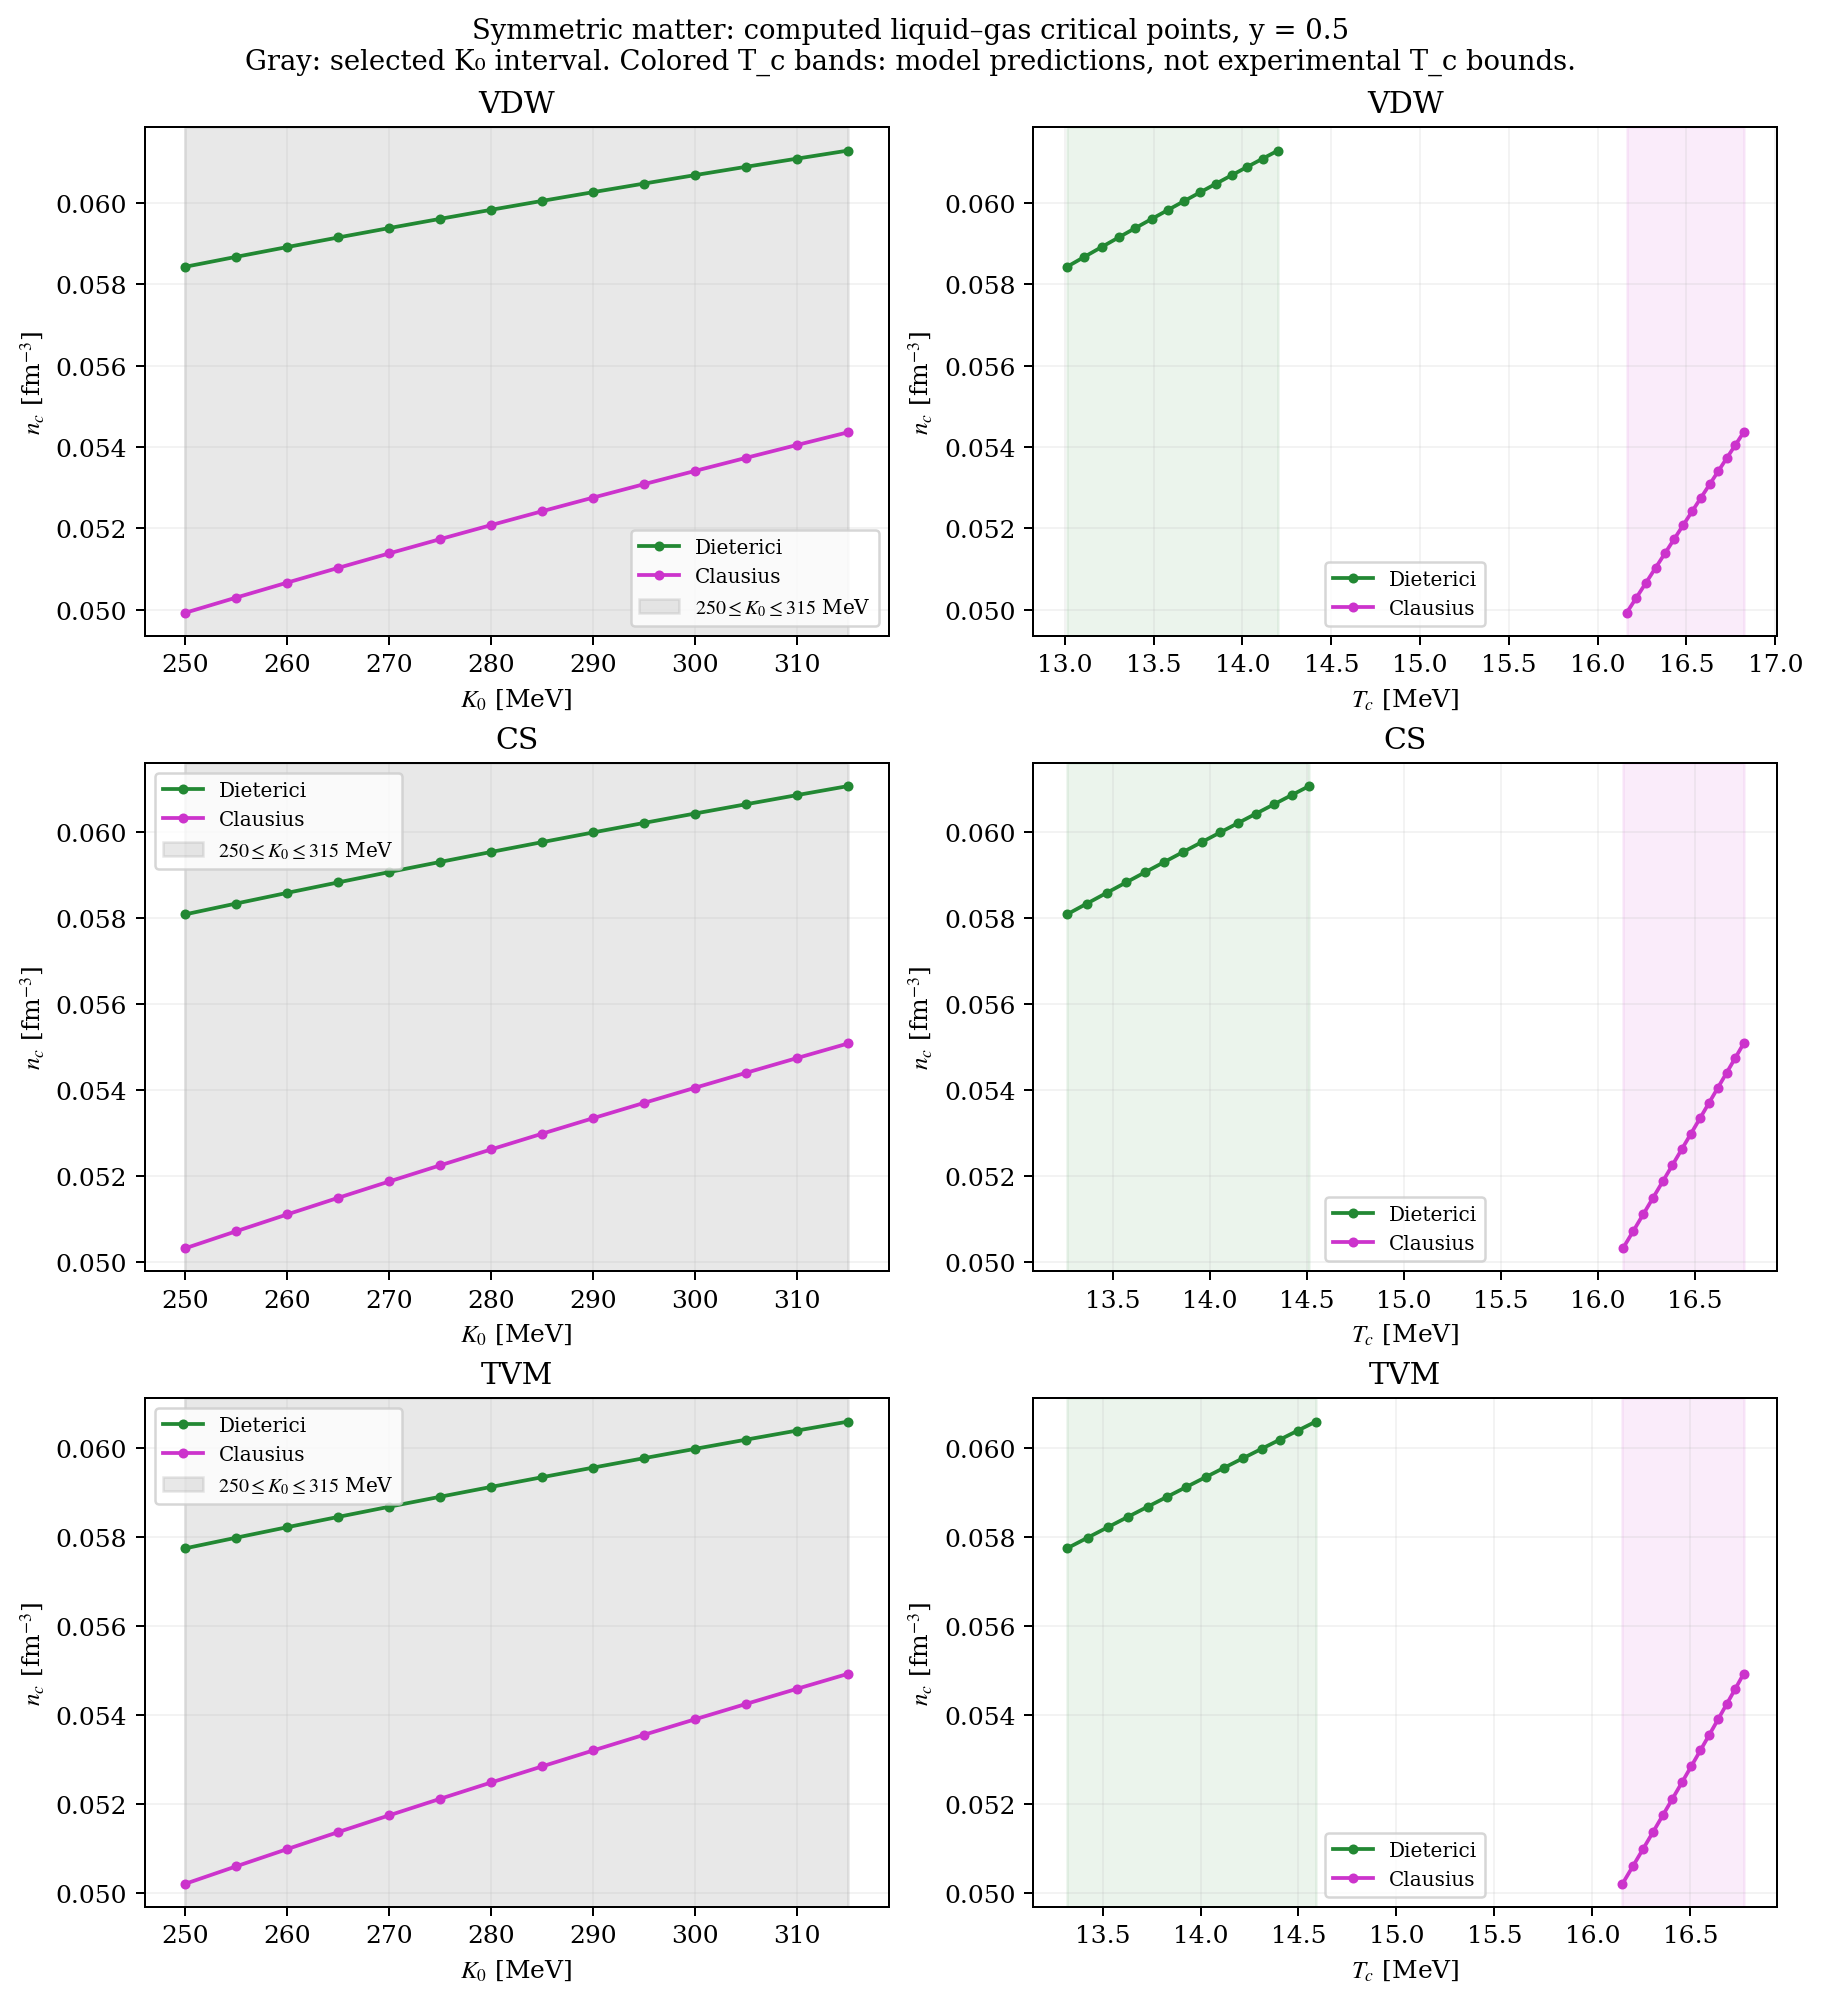

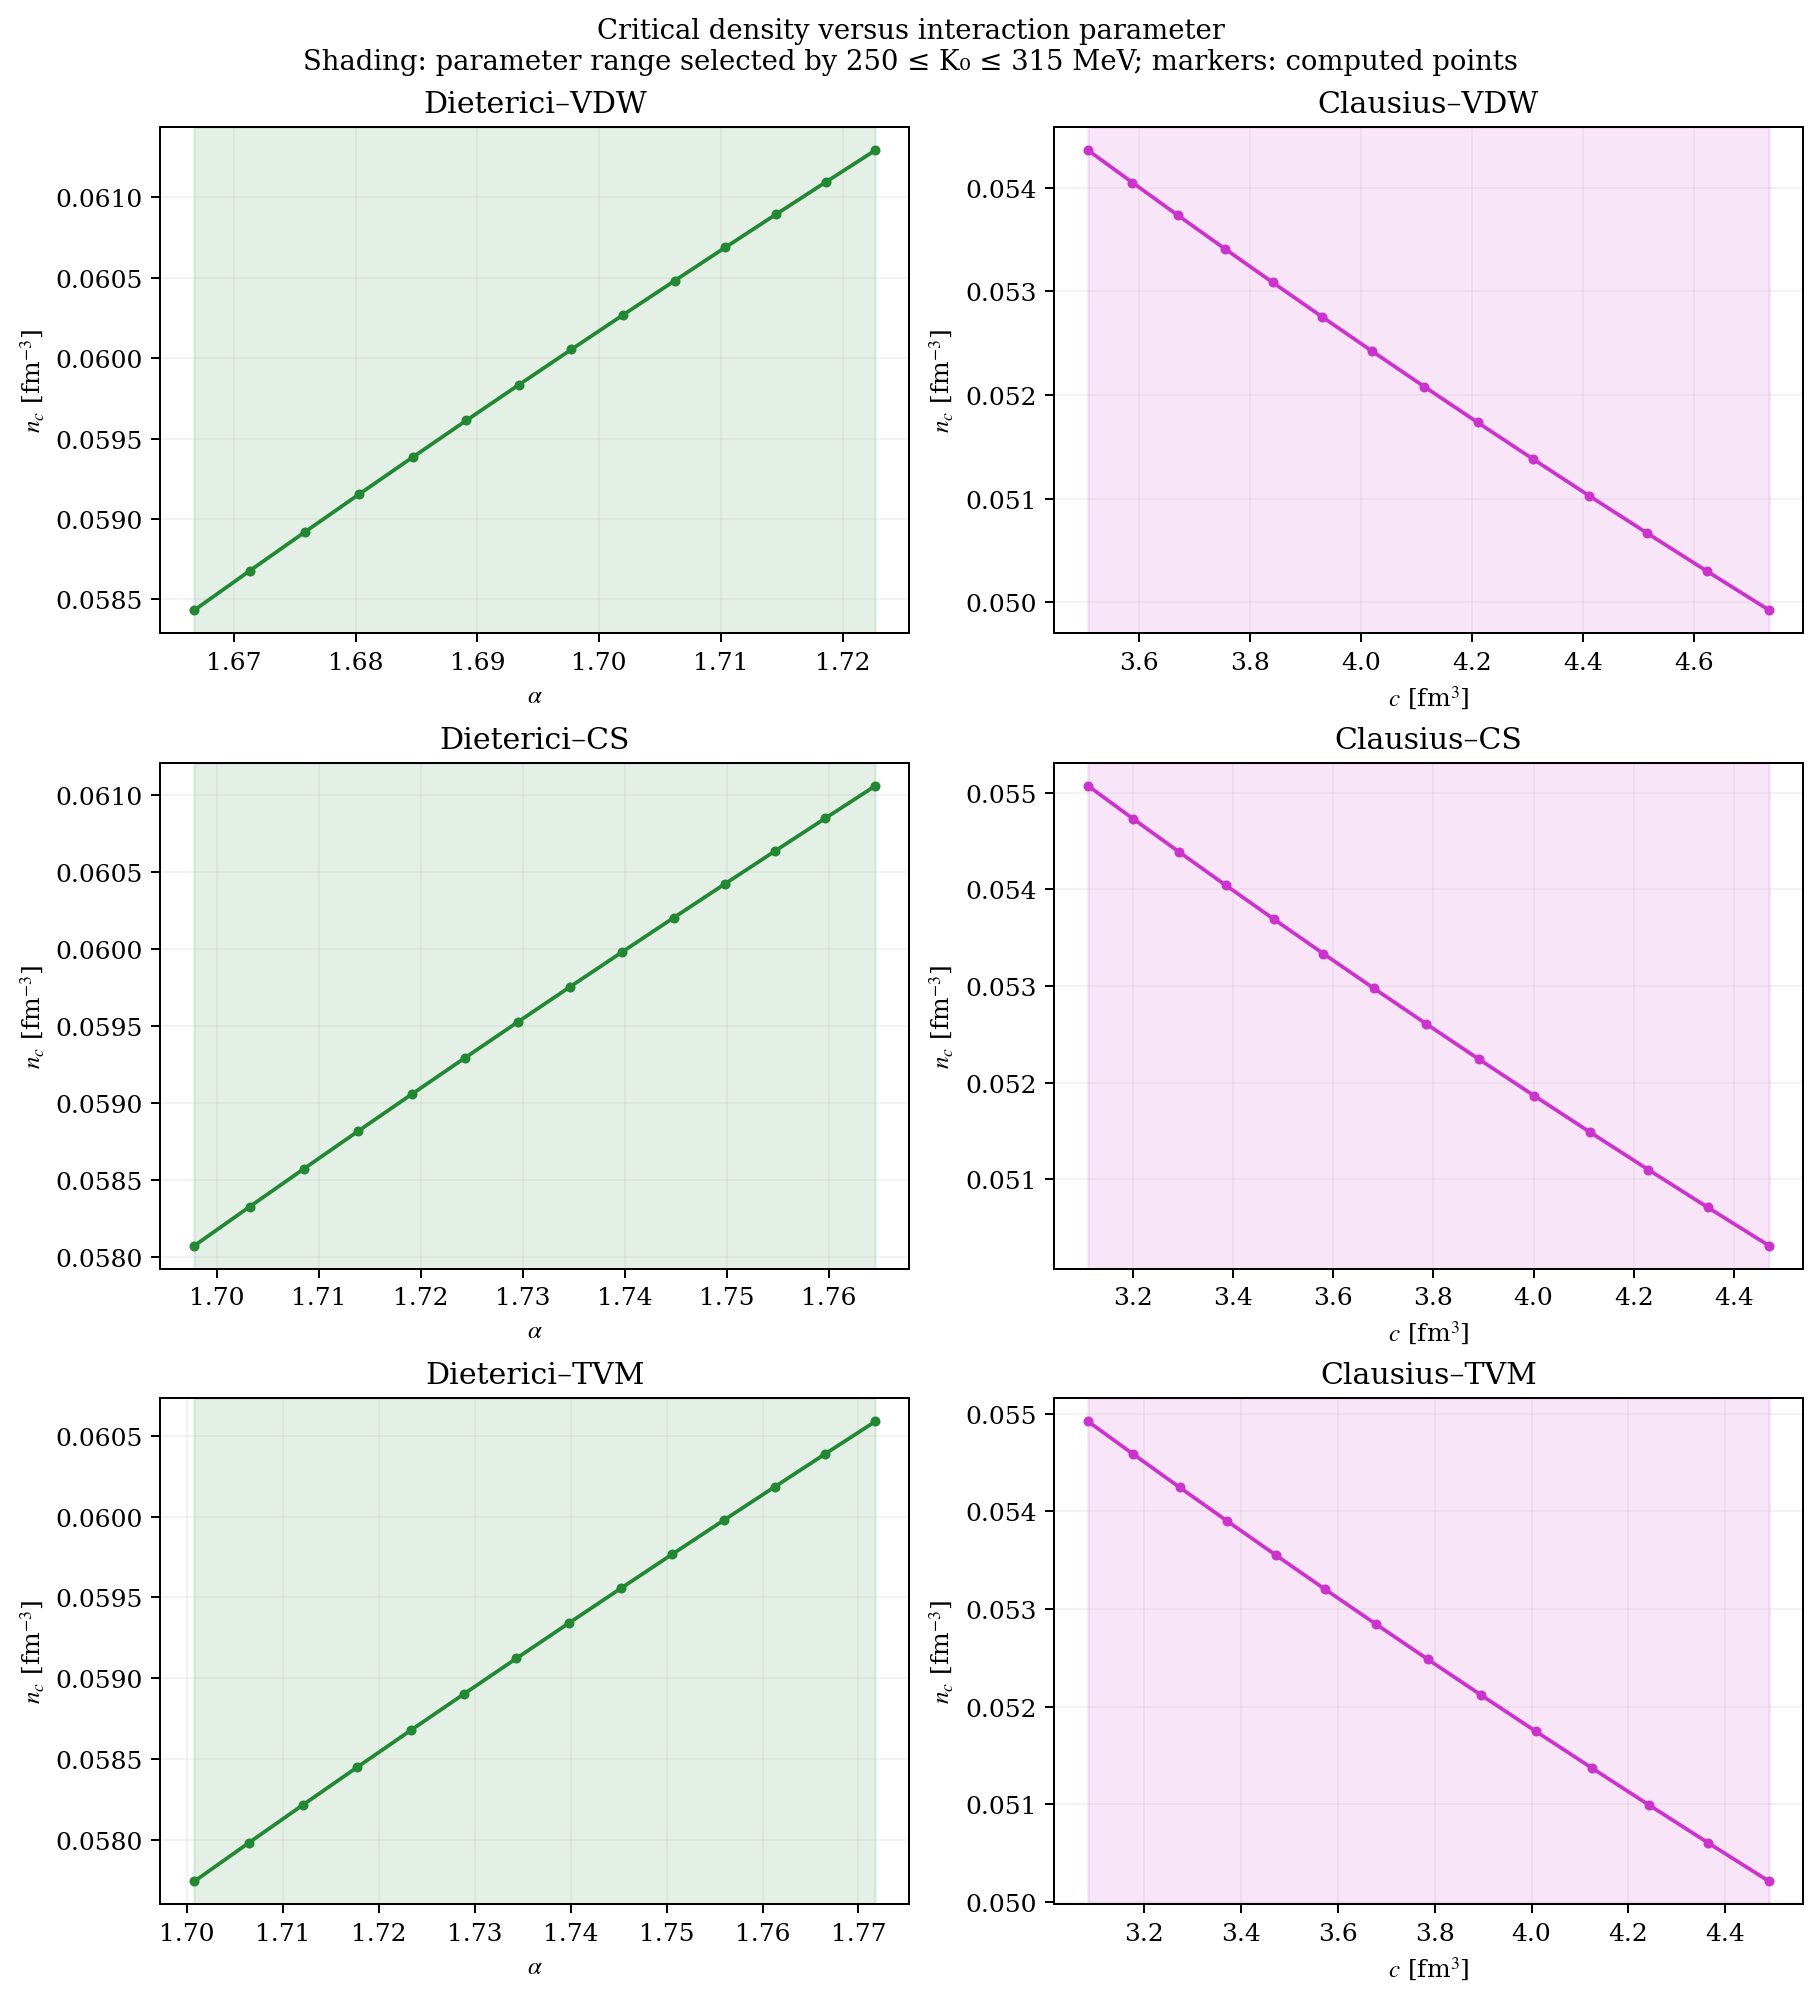

In [3]:
paths = scan.plot_scan(results)
for path in paths:
    display(Image(filename=str(path)))
print('Figuras PNG, PDF y SVG:', scan.OUTPUT)


In [4]:
good = results[results.status == 'ok']
if not good.empty:
    display(good.groupby('model_key').agg(
        points=('K0_MeV', 'size'), parameter_min=('parameter_value', 'min'),
        parameter_max=('parameter_value', 'max'), Tc_min=('Tc_MeV', 'min'),
        Tc_max=('Tc_MeV', 'max'), nc_min=('nc_fm3', 'min'), nc_max=('nc_fm3', 'max')))
    print('Máximo residuo K₀ [MeV]:', (good.K0_MeV-good.K0_target_MeV).abs().max())
    print('Máximo |dP/dn|:', good.dPdn.abs().max())
    print('Máximo |d²P/dn²|:', good.d2Pdn2.abs().max())


Máximo residuo K₀ [MeV]: 1.8763348634820431e-06
Máximo |dP/dn|: 5.2735593669694936e-11
Máximo |d²P/dn²|: 5.60662627435704e-07


,points,parameter_min,parameter_max,Tc_min,Tc_max,nc_min,nc_max
model_key,,,,,,,
clausius_cs,14,3.110066,4.470084,16.130889,16.753221,0.050313,0.055073
clausius_tvm,14,3.083918,4.490403,16.153440,16.771973,0.050208,0.054924
clausius_vdw,14,3.507371,4.735853,16.163321,16.822044,0.049925,0.054364
dieterici_cs,14,1.697808,1.764535,13.264158,14.512108,0.058075,0.061057
dieterici_tvm,14,1.700769,1.771769,13.319050,14.587996,0.057742,0.060589
dieterici_vdw,14,1.666763,1.722673,13.012208,14.199229,0.058434,0.061292
